In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/kaleko/CourseraML/master/ex2/data/ex2data1.txt"
df = pd.read_csv(url, header=None, names=['exam1_score', 'exam2_score', 'admitted'])

print("Shape:", df.shape)
df.head()

Shape: (100, 3)


,exam1_score,exam2_score,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


# Daily Challenge — Logistic Regression for Admission Prediction

**Dataset:** 100 students' two exam scores, with admission outcome (0/1)

## Task 1: Data Exploration

Admitted: 60, Not admitted: 40


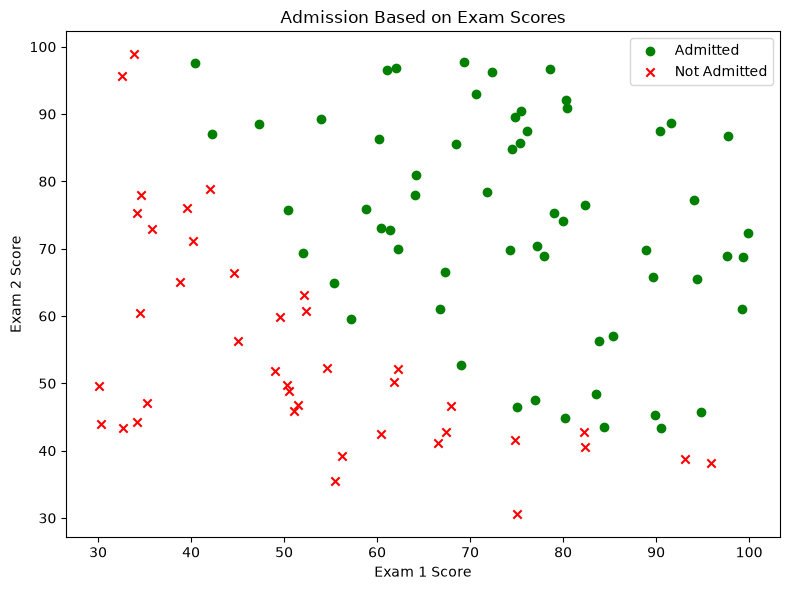

In [2]:
admitted = df[df['admitted'] == 1]
not_admitted = df[df['admitted'] == 0]

print(f"Admitted: {len(admitted)}, Not admitted: {len(not_admitted)}")

plt.figure(figsize=(8, 6))
plt.scatter(admitted['exam1_score'], admitted['exam2_score'], color='green', label='Admitted', marker='o')
plt.scatter(not_admitted['exam1_score'], not_admitted['exam2_score'], color='red', label='Not Admitted', marker='x')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Admission Based on Exam Scores')
plt.legend()
plt.tight_layout()
plt.show()

The scatter plot shows a clear visual pattern: admitted students (green) cluster toward higher scores on both exams, while non-admitted students (red) cluster toward lower scores on both. This diagonal-shaped separation suggests logistic regression should work well here, similar to the clean boundary found in the diabetes classification exercise earlier today.

## Task 2: Applying Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression

X = df[['exam1_score', 'exam2_score']]
y = df['admitted']

model = LogisticRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[0.20535491 0.2005838 ]]
Intercept: [-25.05219314]


## Task 3: Making Predictions and Accuracy

In [4]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X)
accuracy = accuracy_score(y, predictions)

print("First 10 predictions:", predictions[:10])
print("First 10 actual values:", y.values[:10])
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

First 10 predictions: [0 0 0 1 1 0 1 0 1 1]
First 10 actual values: [0 0 0 1 1 0 1 1 1 1]

Accuracy: 0.8900 (89.00%)


## Task 4: Model Evaluation and Interpretation

**Coefficients (Exam1: 0.205, Exam2: 0.201):** both exam scores contribute almost equally to the admission prediction — neither test is weighted significantly more than the other. This suggests the admissions process (as reflected in this data) values both exams as roughly equal indicators of readiness.

**Intercept (-25.05):** a large negative starting point means a student needs solidly strong scores on both exams to be predicted as admitted — there's no "coasting" on just one strong score while the other is weak.

**Accuracy (89.00%):** the model correctly predicts the outcome for 89 out of 100 students. This is a reasonably strong result for a simple two-feature model, consistent with the clear visual separation seen in the scatter plot. The remaining 11% of mistakes likely correspond to students near the decision boundary — those with a genuinely "borderline" combination of scores where the outcome could reasonably go either way, similar to the near-zero example we calculated by hand (a student scoring 60/60 landed almost exactly on the tipping point).

**Comparison to today's earlier exercise:** unlike the Diabetes Classification exercise (which had a severe class imbalance —